# Perform Logistic Regression

In [7]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [8]:
# 2. Load Dataset
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
# 3. Basic Information
print("Shape of Dataset:", df.shape)

Shape of Dataset: (891, 8)


In [22]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['Survived', 'Pclass', 'Gender', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [21]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Gender    891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [19]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Survived    0
Pclass      0
Gender      0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [24]:
# 4. Data Cleaning

# Fill missing Ag\e values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [25]:
# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [27]:
# Drop Cabin column only if it exists

if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

print(df.columns)


Index(['Survived', 'Pclass', 'Gender', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [28]:
# Drop unnecessary columns safely

columns_to_drop = ['Cabin', 'PassengerId', 'Name', 'Ticket']

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("Remaining Columns:")
print(df.columns)

Remaining Columns:
Index(['Survived', 'Pclass', 'Gender', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


In [29]:
# Check missing values again
df.isnull().sum()

Survived    0
Pclass      0
Gender      0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [31]:
# 5. Convert Categorical Data

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Embarked'] = le.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Gender,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


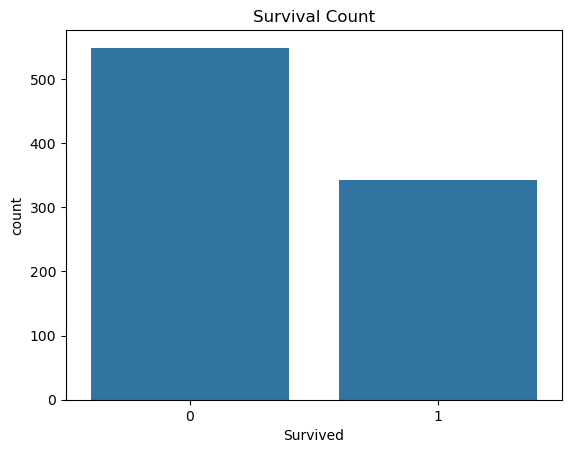

In [32]:
# 6. Data Visualization

# Survival Count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()


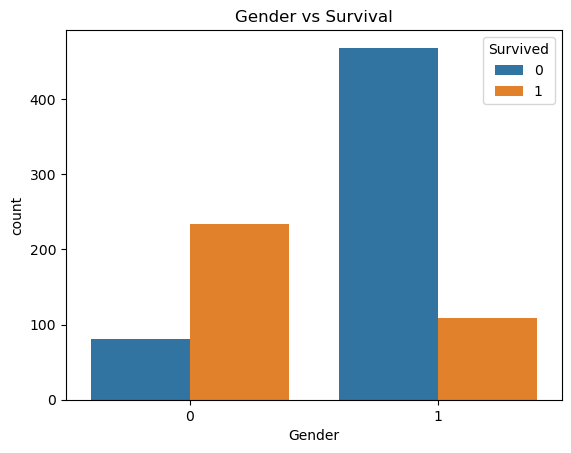

In [34]:
# Gender vs Survival
sns.countplot(x='Gender', hue='Survived', data=df)
plt.title("Gender vs Survival")
plt.show()

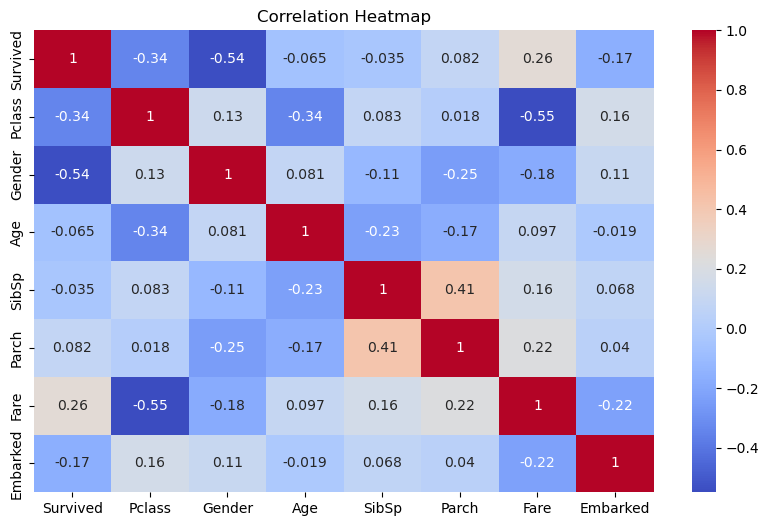

In [35]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [36]:
# 7. Define Features and Target

x = df.drop('Survived', axis=1)

y = df['Survived']

print("Features Shape:", x.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


In [39]:
# 8. Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)

Training Data Shape: (712, 7)
Testing Data Shape: (179, 7)


In [42]:
# 9. Apply Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(x_train, y_train)

print("Model Training Completed")


Model Training Completed


In [44]:
# 10. Prediction
y_pred = model.predict(x_test)

print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 0 0 1 1 1 1 0 1 1]


In [45]:
# 11. Model Evaluation

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8100558659217877

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



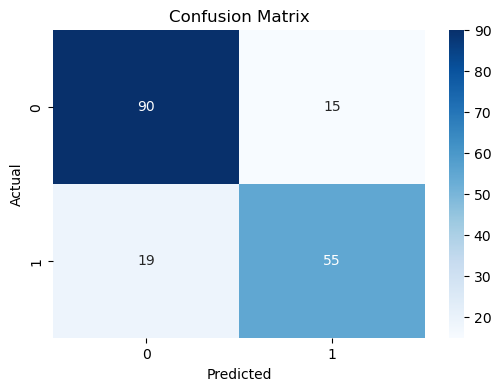

In [46]:
# 12. Confusion Matrix Visualization

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [48]:
# 13. Logistic Regression Equation




In [52]:
coefficients = pd.DataFrame({ 'Feature': x.columns, 'Coefficient': model.coef_[0] }) 
print("\nFeature Importance:") 
print(coefficients.sort_values(by='Coefficient', ascending=False))




Feature Importance:
    Feature  Coefficient
5      Fare     0.002534
2       Age    -0.030433
4     Parch    -0.111850
6  Embarked    -0.218778
3     SibSp    -0.293906
0    Pclass    -0.930679
1    Gender    -2.596996


In [50]:
sample_prediction = model.predict([[ 
    3, # Pclass 
    1, # Sex (Male=1) 
    22, # Age 
    1, # SibSp 
    0, # Parch 
    7.25, # Fare 
    2 # Embarked 
]]) 
print("\nSample Prediction:") 
print("0 = Not Survived") 
print("1 = Survived") 
print(sample_prediction) 
print("\nLogistic Regression Project Completed Successfully.")




Sample Prediction:
0 = Not Survived
1 = Survived
[0]

Logistic Regression Project Completed Successfully.
